# Tier 2 — Dense Retrieval: Full Analysis

**Benchmark:** BSARD official test split — 222 questions  
**Experiments:** 9 dense bi-encoder models (D1–D4c, D6, D7, D10, D10i)  
**Primary metric:** Recall@100 | **Anchor:** `bm25_tuned` (k1=1.5, b=0.5, lemmatize)  
**Corpus:** 22,633 deduplicated articles (`output/bsard_articles_dedup.parquet`)

---

### Experiment map

| ID | Experiment stem | Model | Notes |
|---|---|---|---|
| D1 | `dense_camembert_base_zeroshot` | `camembert-base` | Paper benchmark anchor (~4% R@100) |
| D2 | `dense_camembert_lg_zeroshot` | `sentence-camembert-large` | French-specific |
| D3 | `dense_me5_base_zeroshot` | `multilingual-e5-base` | Multilingual baseline |
| D4 | `dense_me5_large_zeroshot` | `multilingual-e5-large` | Multilingual candidate |
| D4c | `dense_bge_m3_zeroshot` | `BAAI/bge-m3` | Long-context (1024 tok), CLS pooling |
| D6 | `dense_mpnet_multi_zeroshot` | `paraphrase-mpnet-base-v2` | 128-token reference only |
| D7 | `dense_me5_large_concat2x_zeroshot` | `multilingual-e5-large` | Field-weighting ablation winner ★ |
| D10 | `dense_qwen3_0_6b_zeroshot` | `Qwen/Qwen3-Embedding-0.6B` | Decoder-only LLM backbone |
| D10i | `dense_qwen3_0_6b_instruct_zeroshot` | `Qwen/Qwen3-Embedding-0.6B` | Qwen3 + legal instruction prefix |

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

ROOT             = Path().resolve().parent.parent
DENSE_DIR        = ROOT / 'output' / 'results' / 'dense_retrieval'
SPARSE_DIR       = ROOT / 'output' / 'results' / 'sparse_retrieval'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

# ── Load all dense results (test split) ──────────────────────────────────────
raw = {}
for f in sorted(DENSE_DIR.glob('*_test.json')):
    if f.stem.startswith('_'):   # skip _sel_* and _anchor_* files
        continue
    d = json.loads(f.read_text(encoding='utf-8'))
    stem = d['experiment_id'].replace('_test', '')
    raw[stem] = d

# ── Load sparse reference results ────────────────────────────────────────────
sparse_raw = {}
for f in SPARSE_DIR.glob('*_test.json'):
    d = json.loads(f.read_text(encoding='utf-8'))
    sparse_raw[d['experiment_id'].replace('_test', '')] = d

SPARSE_ANCHOR_KEY  = 'bm25_tuned_k11.5_b0.25'   # closest saved anchor (k1=1.5, b=0.25)
SPARSE_BEST_KEY    = 'bm25_lemmatize_concat_2x'   # best sparse config (Tier 3 component)

print(f'Dense  experiments loaded : {len(raw)}')
print(f'Sparse experiments loaded : {len(sparse_raw)}')
for k in sorted(raw):
    m = raw[k]['metrics']
    print(f'  {k:<50}  R@10={m["Recall@10"]:.4f}  R@100={m["Recall@100"]:.4f}')

Dense  experiments loaded : 9
Sparse experiments loaded : 12
  dense_bge_m3_zeroshot                               R@10=0.3142  R@100=0.5921
  dense_camembert_base_zeroshot                       R@10=0.0077  R@100=0.0169
  dense_camembert_lg_zeroshot                         R@10=0.3069  R@100=0.5833
  dense_me5_base_zeroshot                             R@10=0.2254  R@100=0.4915
  dense_me5_large_concat2x_zeroshot                   R@10=0.3420  R@100=0.6215
  dense_me5_large_zeroshot                            R@10=0.2959  R@100=0.5941
  dense_mpnet_multi_zeroshot                          R@10=0.2108  R@100=0.4047
  dense_qwen3_0_6b_instruct_zeroshot                  R@10=0.3389  R@100=0.5974
  dense_qwen3_0_6b_zeroshot                           R@10=0.3240  R@100=0.5822


In [2]:
# ── Display names and visual style ───────────────────────────────────────────
SHORT = {
    'dense_camembert_base_zeroshot':       'CamemBERT-base (D1)',
    'dense_camembert_lg_zeroshot':         'CamemBERT-large (D2)',
    'dense_me5_base_zeroshot':             'mE5-base (D3)',
    'dense_me5_large_zeroshot':            'mE5-large (D4)',
    'dense_bge_m3_zeroshot':               'BGE-M3 (D4c)',
    'dense_mpnet_multi_zeroshot':          'MPNet-128 (D6)',
    'dense_me5_large_concat2x_zeroshot':   'mE5-large concat_2x (D7) [best]',
    'dense_qwen3_0_6b_zeroshot':           'Qwen3-0.6B (D10)',
    'dense_qwen3_0_6b_instruct_zeroshot':  'Qwen3-0.6B instruct (D10i)',
}

# Architecture family colours
COLORS = {
    'dense_camembert_base_zeroshot':       '#aec6cf',   # light blue
    'dense_camembert_lg_zeroshot':         '#4c72b0',   # blue
    'dense_me5_base_zeroshot':             '#a8d8a8',   # light green
    'dense_me5_large_zeroshot':            '#27ae60',   # green
    'dense_bge_m3_zeroshot':               '#e67e22',   # orange
    'dense_mpnet_multi_zeroshot':          '#bdc3c7',   # grey (reference)
    'dense_me5_large_concat2x_zeroshot':   '#1a7d40',   # dark green (winner)
    'dense_qwen3_0_6b_zeroshot':           '#8e44ad',   # purple
    'dense_qwen3_0_6b_instruct_zeroshot':  '#6c3483',   # dark purple
}

SPARSE_COLOR  = '#e74c3c'   # red — sparse anchor reference
EXCLUDED = {'dense_camembert_base_zeroshot', 'dense_mpnet_multi_zeroshot'}  # not for Tier 3 selection

## A. Full Results Table — All Models × Key Metrics

In [3]:
rows = []
for stem, d in raw.items():
    m   = d['metrics']
    sig = d.get('significance_vs_anchor', {})
    aud = d.get('token_length_audit', {})
    hp  = d['hyperparameters']
    rows.append({
        'Experiment':   SHORT.get(stem, stem),
        'Model':        hp.get('model_name', ''),
        'max_seq':      hp.get('max_seq_length', 0),
        'dim':          hp.get('embedding_dim', 0),
        'field_wt':     d['preprocessing']['field_weighting'],
        'R@10':         m.get('Recall@10', 0),
        'R@100':        m.get('Recall@100', 0),
        'R@200':        m.get('Recall@200', 0),
        'R@500':        m.get('Recall@500', 0),
        'MRR@10':       m.get('MRR@10', 0),
        'MRR@100':      m.get('MRR@100', 0),
        'MAP@100':      m.get('MAP@100', 0),
        'NDCG@10':      m.get('NDCG@10', 0),
        'lat_ms':       m.get('T0/latency_mean_ms', d.get('latency_ms_mean', 0)),
        'trunc%':       aud.get('fraction_truncated', 0),
        'p_r100':       sig.get('p_value_recall100'),
        'sig':          sig.get('significant'),
    })

df = pd.DataFrame(rows).sort_values('R@100', ascending=False).reset_index(drop=True)

# Append sparse reference rows
def _sparse_row(key, label):
    if key not in sparse_raw: return None
    m = sparse_raw[key]['metrics']
    return {'Experiment': label, 'Model': key, 'max_seq': '-', 'dim': '-',
            'field_wt': sparse_raw[key]['preprocessing']['field_weighting'],
            'R@10': m.get('Recall@10',0), 'R@100': m.get('Recall@100',0),
            'R@200': m.get('Recall@200',0), 'R@500': m.get('Recall@500',0),
            'MRR@10': m.get('MRR@10',0), 'MRR@100': m.get('MRR@100',0),
            'MAP@100': m.get('MAP@100',0), 'NDCG@10': m.get('NDCG@10',0),
            'lat_ms': m.get('T0/latency_mean_ms',0), 'trunc%': None,
            'p_r100': None, 'sig': None}

sparse_refs = pd.DataFrame(filter(None, [
    _sparse_row(SPARSE_BEST_KEY,  '[SPARSE] bm25_lemmatize_concat_2x'),
    _sparse_row(SPARSE_ANCHOR_KEY,'[SPARSE] bm25_tuned (k1=1.5 b=0.25)'),
]))

display_df = pd.concat([df, sparse_refs], ignore_index=True)

fmt = {
    'R@10': '{:.4f}', 'R@100': '{:.4f}', 'R@200': '{:.4f}', 'R@500': '{:.4f}',
    'MRR@10': '{:.4f}', 'MRR@100': '{:.4f}', 'MAP@100': '{:.4f}', 'NDCG@10': '{:.4f}',
    'lat_ms': '{:.1f}', 'trunc%': '{:.1%}', 'p_r100': '{:.3f}',
}
display_cols = ['Experiment', 'R@10', 'R@100', 'R@200', 'R@500',
                'MRR@100', 'MAP@100', 'NDCG@10', 'lat_ms', 'trunc%', 'p_r100', 'sig']
display(display_df[display_cols].style.format(fmt, na_rep='—').hide(axis='index'))

Experiment,R@10,R@100,R@200,R@500,MRR@100,MAP@100,NDCG@10,lat_ms,trunc%,p_r100,sig
mE5-large concat_2x (D7) [best],0.3420,0.6215,0.6978,0.7732,0.3217,0.2157,0.2699,321.4,9.4%,0.000,True
Qwen3-0.6B instruct (D10i),0.3389,0.5974,0.6633,0.7722,0.3276,0.2063,0.2677,63.4,11.0%,0.004,True
mE5-large (D4),0.2959,0.5941,0.6753,0.7540,0.2995,0.1732,0.2300,281.2,9.4%,0.009,True
BGE-M3 (D4c),0.3142,0.5921,0.6954,0.7961,0.3034,0.1815,0.2420,280.3,2.5%,0.015,True
CamemBERT-large (D2),0.3069,0.5833,0.6693,0.7689,0.2522,0.1620,0.2154,241.0,7.4%,0.048,True
Qwen3-0.6B (D10),0.3240,0.5822,0.6524,0.7548,0.3171,0.1991,0.2594,61.7,11.0%,0.027,True
mE5-base (D3),0.2254,0.4915,0.5699,0.6858,0.2448,0.1404,0.1820,121.3,9.4%,0.206,False
MPNet-128 (D6),0.2108,0.4047,0.5236,0.6417,0.1970,0.1093,0.1540,107.7,49.3%,0.001,True
CamemBERT-base (D1),0.0077,0.0169,0.0209,0.0562,0.0216,0.0072,0.0096,90.1,7.4%,0.000,True
[SPARSE] bm25_lemmatize_concat_2x,0.2572,0.5312,0.5312,0.5312,0.2520,0.1678,0.2102,69.7,—,—,—


## B. BSARD Paper Benchmark Reference

Masson & Joty (2022), Table 2. Zero-shot and fine-tuned CamemBERT bi-encoder baselines.
D1 replicates the zero-shot CamemBERT result; D5 (paper checkpoint) was unavailable as of 2026-04.

In [4]:
paper_rows = [
    {'System': 'TF-IDF (zero-shot)',              'R@100': 40.13, 'MAP@100': 8.69,  'MRR@100': 12.98, 'Note': 'Paper Table 2'},
    {'System': 'BM25 (zero-shot)',                'R@100': 51.33, 'MAP@100': 16.04, 'MRR@100': 24.59, 'Note': 'Paper Table 2'},
    {'System': 'CamemBERT siamese (zero-shot)',   'R@100':  4.21, 'MAP@100':  0.50, 'MRR@100':  2.04, 'Note': 'Paper Table 2'},
    {'System': 'CamemBERT siamese (fine-tuned)',  'R@100': 71.63, 'MAP@100': 35.44, 'MRR@100': 43.52, 'Note': 'Paper Table 2'},
    {'System': 'CamemBERT two-tower (fine-tuned)','R@100': 74.78, 'MAP@100': 35.67, 'MRR@100': 42.46, 'Note': 'Paper Table 2 (best)'},
]

# Our D1 replication
d1 = raw.get('dense_camembert_base_zeroshot')
if d1:
    paper_rows.append({
        'System': 'CamemBERT-base (ours, zero-shot D1)',
        'R@100':   round(d1['metrics']['Recall@100'] * 100, 2),
        'MAP@100': round(d1['metrics']['MAP@100'] * 100, 2),
        'MRR@100': round(d1['metrics']['MRR@100'] * 100, 2),
        'Note': 'Replication target: ~4.21%',
    })

paper_df = pd.DataFrame(paper_rows)
display(paper_df.style.hide(axis='index').format({'R@100': '{:.2f}', 'MAP@100': '{:.2f}', 'MRR@100': '{:.2f}'}))

System,R@100,MAP@100,MRR@100,Note
TF-IDF (zero-shot),40.13,8.69,12.98,Paper Table 2
BM25 (zero-shot),51.33,16.04,24.59,Paper Table 2
CamemBERT siamese (zero-shot),4.21,0.50,2.04,Paper Table 2
CamemBERT siamese (fine-tuned),71.63,35.44,43.52,Paper Table 2
CamemBERT two-tower (fine-tuned),74.78,35.67,42.46,Paper Table 2 (best)
"CamemBERT-base (ours, zero-shot D1)",1.69,0.72,2.16,Replication target: ~4.21%


## 1. Recall@k Curves — All Dense Models vs Sparse Anchor

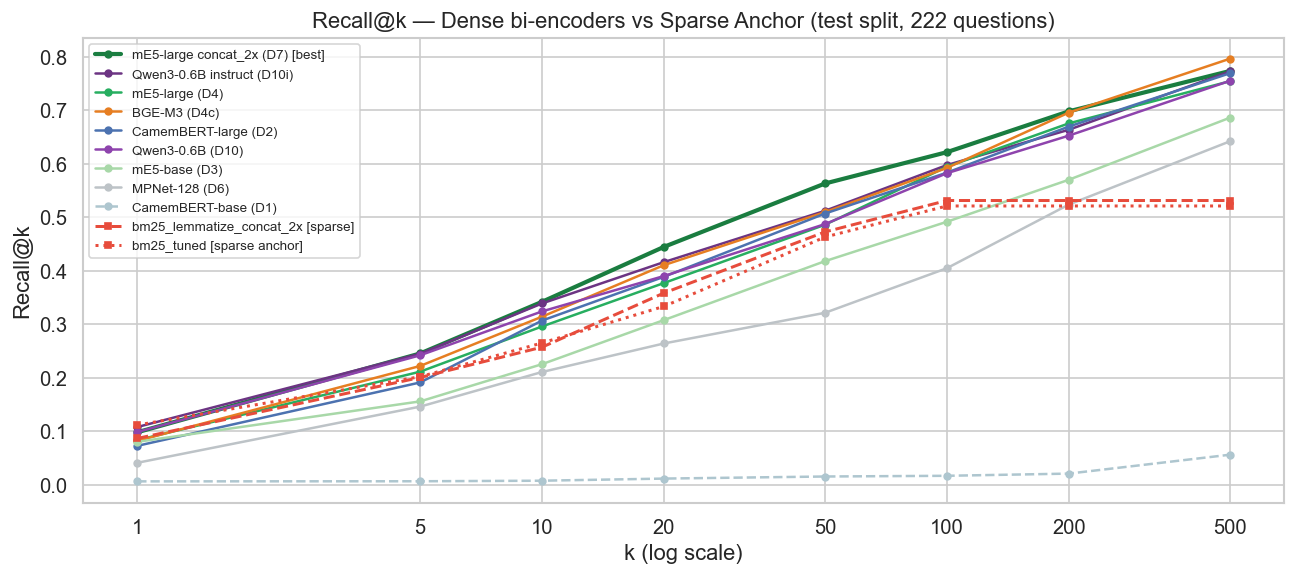

In [5]:
K_VALS = [1, 5, 10, 20, 50, 100, 200, 500]
K_COLS = [f'Recall@{k}' for k in K_VALS]

fig, ax = plt.subplots(figsize=(11, 5))

for stem in sorted(raw, key=lambda s: raw[s]['metrics'].get('Recall@100', 0), reverse=True):
    m  = raw[stem]['metrics']
    ys = [m.get(c, 0) for c in K_COLS]
    lw = 2.5 if 'concat2x' in stem else 1.5
    ls = '--' if stem == 'dense_camembert_base_zeroshot' else '-'
    ax.plot(K_VALS, ys, label=SHORT.get(stem, stem), color=COLORS.get(stem, '#333'),
            linewidth=lw, linestyle=ls, marker='o', markersize=4)

# Sparse reference lines
for key, label, ls in [
    (SPARSE_BEST_KEY,  'bm25_lemmatize_concat_2x [sparse]', '--'),
    (SPARSE_ANCHOR_KEY,'bm25_tuned [sparse anchor]',        ':'),
]:
    if key in sparse_raw:
        m  = sparse_raw[key]['metrics']
        ys = [m.get(c, 0) for c in K_COLS]
        ax.plot(K_VALS, ys, label=label, color=SPARSE_COLOR,
                linewidth=1.8, linestyle=ls, marker='s', markersize=4)

ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k — Dense bi-encoders vs Sparse Anchor (test split, 222 questions)')
ax.set_xticks(K_VALS)
ax.set_xticklabels(K_VALS)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## 2. R@100 Bar Chart — All Models Ranked

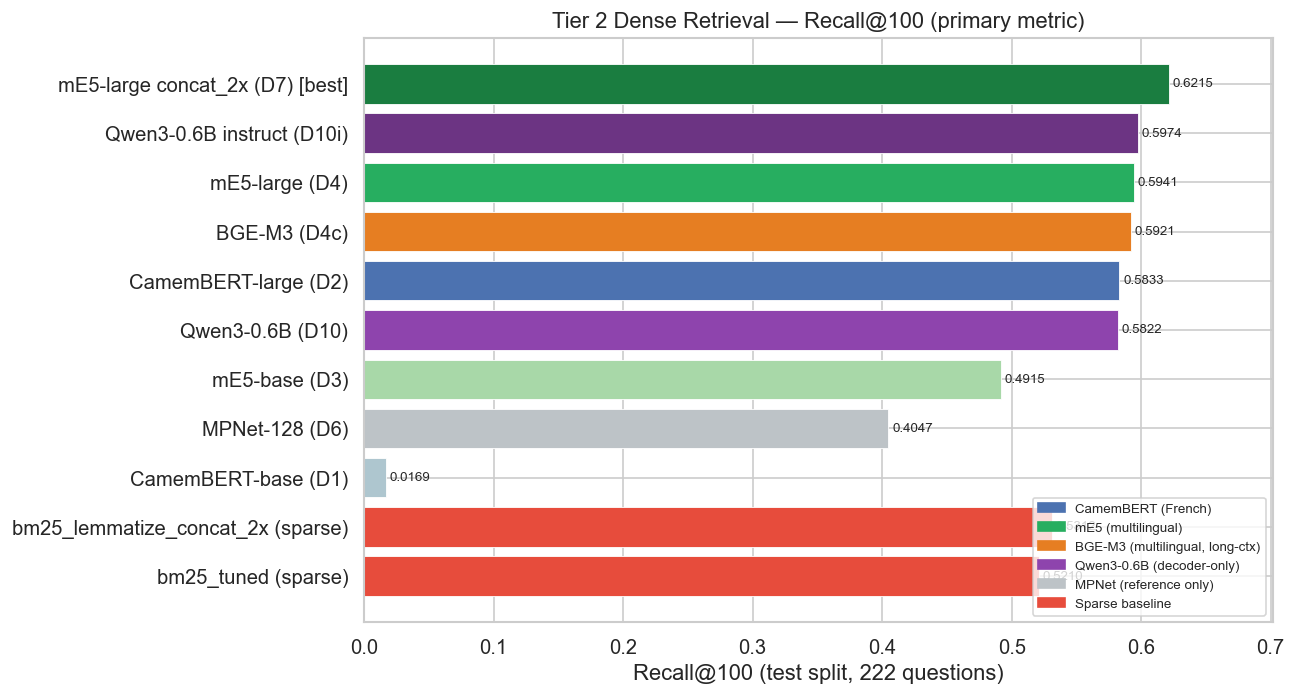

In [6]:
order = sorted(raw, key=lambda s: raw[s]['metrics']['Recall@100'])
vals  = [raw[s]['metrics']['Recall@100'] for s in order]
cols  = [COLORS.get(s, '#333') for s in order]
lbls  = [SHORT.get(s, s) for s in order]

# Sparse references
sp_vals, sp_lbls, sp_cols = [], [], []
for key, lbl in [(SPARSE_ANCHOR_KEY,'bm25_tuned (sparse)'), (SPARSE_BEST_KEY,'bm25_lemmatize_concat_2x (sparse)')]:
    if key in sparse_raw:
        sp_vals.append(sparse_raw[key]['metrics']['Recall@100'])
        sp_lbls.append(lbl); sp_cols.append(SPARSE_COLOR)

all_vals = sp_vals + vals
all_lbls = sp_lbls + lbls
all_cols = sp_cols + cols

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(all_lbls, all_vals, color=all_cols, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, all_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Recall@100 (test split, 222 questions)')
ax.set_title('Tier 2 Dense Retrieval — Recall@100 (primary metric)')
ax.set_xlim(0, min(1.0, max(all_vals) + 0.08))

# Legend patches
legend_items = [
    mpatches.Patch(color='#4c72b0', label='CamemBERT (French)'),
    mpatches.Patch(color='#27ae60', label='mE5 (multilingual)'),
    mpatches.Patch(color='#e67e22', label='BGE-M3 (multilingual, long-ctx)'),
    mpatches.Patch(color='#8e44ad', label='Qwen3-0.6B (decoder-only)'),
    mpatches.Patch(color='#bdc3c7', label='MPNet (reference only)'),
    mpatches.Patch(color=SPARSE_COLOR, label='Sparse baseline'),
]
ax.legend(handles=legend_items, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 3. Truncation Analysis — BGE-M3 vs mE5 Family (Hypothesis H6)

**H6:** BGE-M3 (1024-token context) will outperform mE5 models (512-token) on long articles  
due to its extended context window, but perform comparably on short articles.

Model,max_seq,mean_tok,p90_tok,max_tok,trunc%,R@10,R@100,NDCG@10
mE5-base (512 tok),512,222,498,9110,9.4%,0.2254,0.4915,0.1820
mE5-large (512 tok),512,222,498,9110,9.4%,0.2959,0.5941,0.2300
BGE-M3 (1024 tok),1024,222,498,9110,2.5%,0.3142,0.5921,0.2420


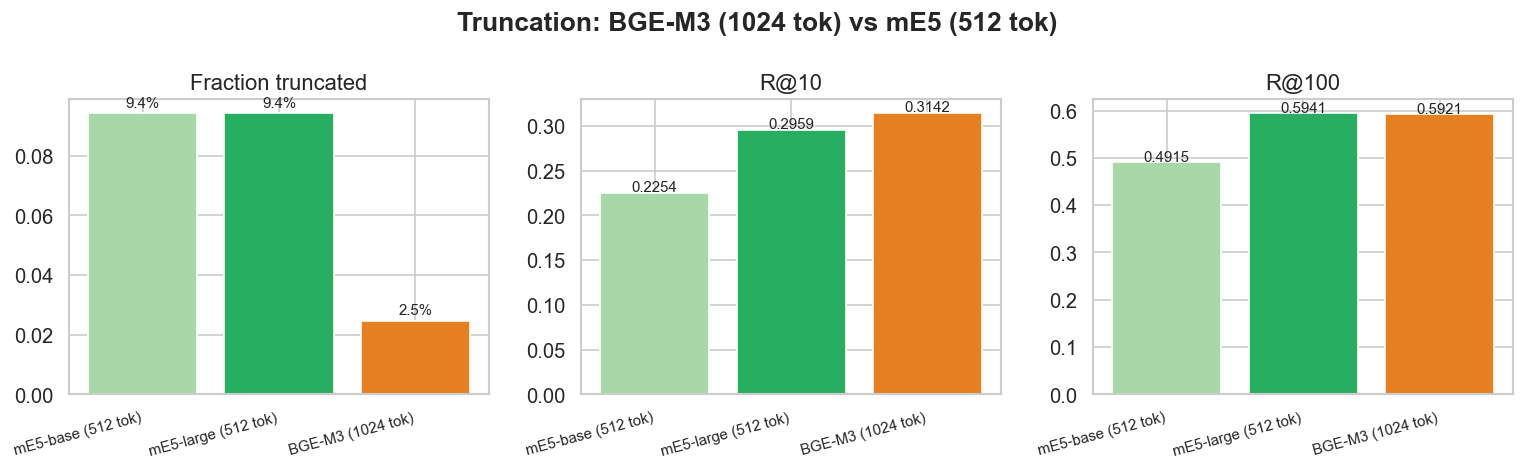

In [7]:
trunc_exps = [
    ('dense_me5_base_zeroshot',   'mE5-base (512 tok)'),
    ('dense_me5_large_zeroshot',  'mE5-large (512 tok)'),
    ('dense_bge_m3_zeroshot',     'BGE-M3 (1024 tok)'),
]

trunc_rows = []
for stem, label in trunc_exps:
    if stem not in raw: continue
    d   = raw[stem]
    aud = d['token_length_audit']
    m   = d['metrics']
    trunc_rows.append({
        'Model':       label,
        'max_seq':     d['hyperparameters']['max_seq_length'],
        'mean_tok':    aud['mean_tokens'],
        'p90_tok':     aud['p90_tokens'],
        'max_tok':     aud['max_tokens_observed'],
        'trunc%':      aud['fraction_truncated'],
        'R@10':        m['Recall@10'],
        'R@100':       m['Recall@100'],
        'NDCG@10':     m['NDCG@10'],
    })
trunc_df = pd.DataFrame(trunc_rows)
display(trunc_df.style.hide(axis='index').format({
    'mean_tok': '{:.0f}', 'p90_tok': '{:.0f}', 'max_tok': '{:.0f}',
    'trunc%': '{:.1%}', 'R@10': '{:.4f}', 'R@100': '{:.4f}', 'NDCG@10': '{:.4f}',
}))

# Bar comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (metric, title) in zip(axes, [('trunc%','Fraction truncated'), ('R@10','R@10'), ('R@100','R@100')]):
    bars = ax.bar(trunc_df['Model'], trunc_df[metric],
                  color=['#a8d8a8','#27ae60','#e67e22'], edgecolor='white')
    for bar, val in zip(bars, trunc_df[metric]):
        fmt_val = f'{val:.1%}' if metric == 'trunc%' else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                fmt_val, ha='center', fontsize=9)
    ax.set_title(title); plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
plt.suptitle('Truncation: BGE-M3 (1024 tok) vs mE5 (512 tok)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Architecture: Encoder-Only vs Decoder-Only Qwen3 (Hypothesis H8)

**H8:** Qwen3-Embedding-0.6B (decoder-only LLM backbone, last-token pooling) will outperform  
encoder-only models of similar or smaller parameter count on statutory retrieval.

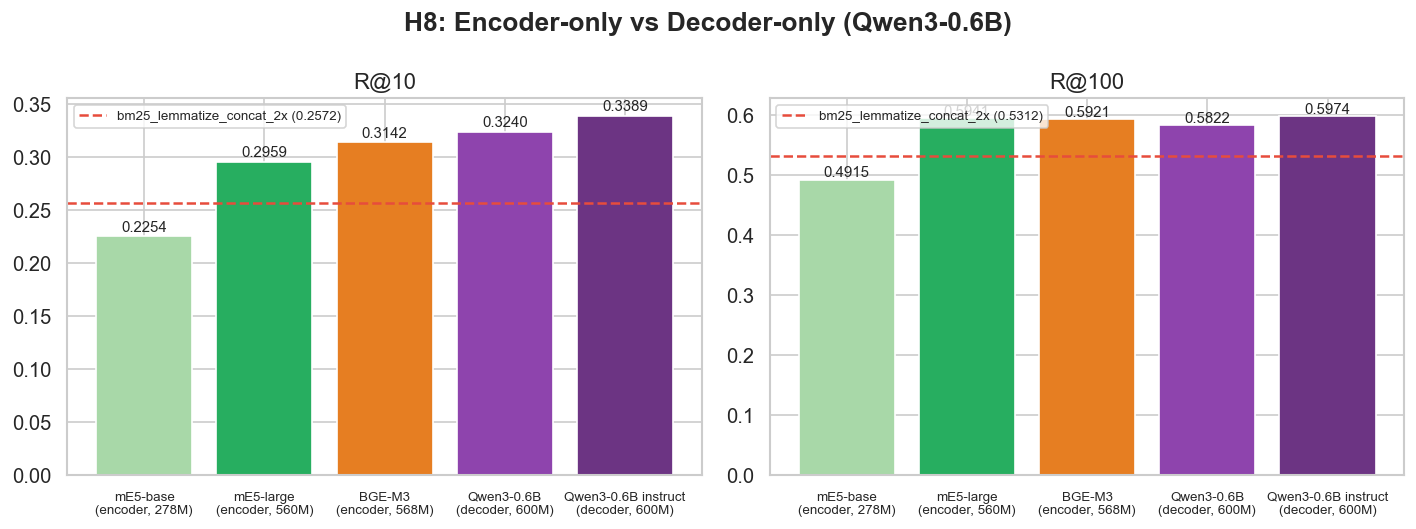

In [8]:
arch_exps = [
    ('dense_me5_base_zeroshot',             'mE5-base\n(encoder, 278M)'),
    ('dense_me5_large_zeroshot',            'mE5-large\n(encoder, 560M)'),
    ('dense_bge_m3_zeroshot',               'BGE-M3\n(encoder, 568M)'),
    ('dense_qwen3_0_6b_zeroshot',           'Qwen3-0.6B\n(decoder, 600M)'),
    ('dense_qwen3_0_6b_instruct_zeroshot',  'Qwen3-0.6B instruct\n(decoder, 600M)'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (metric, title) in zip(axes, [('Recall@10','R@10'), ('Recall@100','R@100')]):
    stems  = [s for s, _ in arch_exps if s in raw]
    labels = [l for s, l in arch_exps if s in raw]
    vals   = [raw[s]['metrics'][metric] for s in stems]
    colors = [COLORS.get(s, '#555') for s in stems]
    bars   = ax.bar(labels, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=9)
    # Sparse reference line
    if SPARSE_BEST_KEY in sparse_raw:
        ref = sparse_raw[SPARSE_BEST_KEY]['metrics'][metric]
        ax.axhline(ref, color=SPARSE_COLOR, linestyle='--', linewidth=1.5,
                   label=f'bm25_lemmatize_concat_2x ({ref:.4f})')
        ax.legend(fontsize=8)
    ax.set_title(title); plt.setp(ax.get_xticklabels(), fontsize=8)
plt.suptitle('H8: Encoder-only vs Decoder-only (Qwen3-0.6B)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. mE5 Model Scale: Base vs Large (Hypothesis H3)

**H3:** mE5-large may not consistently outperform mE5-base on statutory text —  
domain specificity reduces the benefit of larger scale.

Model,Recall@10,Recall@100,MRR@100,MAP@100,NDCG@10
mE5-base (D3),0.2254,0.4915,0.2448,0.1404,0.1820
mE5-large (D4),0.2959,0.5941,0.2995,0.1732,0.2300
mE5-large concat_2x (D7),0.3420,0.6215,0.3217,0.2157,0.2699


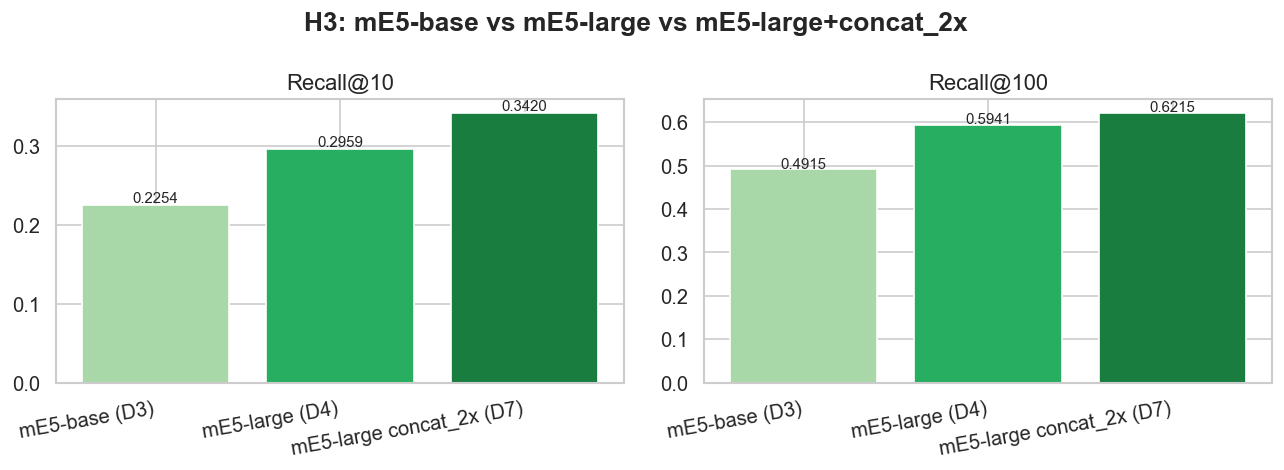

In [9]:
scale_exps = ['dense_me5_base_zeroshot', 'dense_me5_large_zeroshot', 'dense_me5_large_concat2x_zeroshot']
scale_lbls = ['mE5-base (D3)', 'mE5-large (D4)', 'mE5-large concat_2x (D7)']
metrics_compare = ['Recall@10', 'Recall@100', 'MRR@100', 'MAP@100', 'NDCG@10']

scale_df = pd.DataFrame([
    {'Model': lbl, **{m: raw[s]['metrics'][m] for m in metrics_compare}}
    for s, lbl in zip(scale_exps, scale_lbls) if s in raw
])

display(scale_df.style.hide(axis='index').format({m: '{:.4f}' for m in metrics_compare}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(scale_df))
for ax, metric in zip(axes, ['Recall@10', 'Recall@100']):
    bars = ax.bar(scale_df['Model'], scale_df[metric],
                  color=['#a8d8a8','#27ae60','#1a7d40'], edgecolor='white')
    for bar, val in zip(bars, scale_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontsize=9)
    ax.set_title(metric); plt.setp(ax.get_xticklabels(), rotation=10, ha='right')
plt.suptitle('H3: mE5-base vs mE5-large vs mE5-large+concat_2x', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. French-Specific vs Multilingual (Hypothesis H2)

**H2:** French-specific models (`sentence-camembert-large`) may underperform multilingual mE5-large  
in zero-shot despite domain specificity, due to mE5's massive multilingual retrieval pre-training.

Model,Recall@10,Recall@100,MRR@100,MAP@100
CamemBERT-large (French),0.3069,0.5833,0.2522,0.1620
mE5-base (multilingual),0.2254,0.4915,0.2448,0.1404
mE5-large (multilingual),0.2959,0.5941,0.2995,0.1732
BGE-M3 (multilingual),0.3142,0.5921,0.3034,0.1815


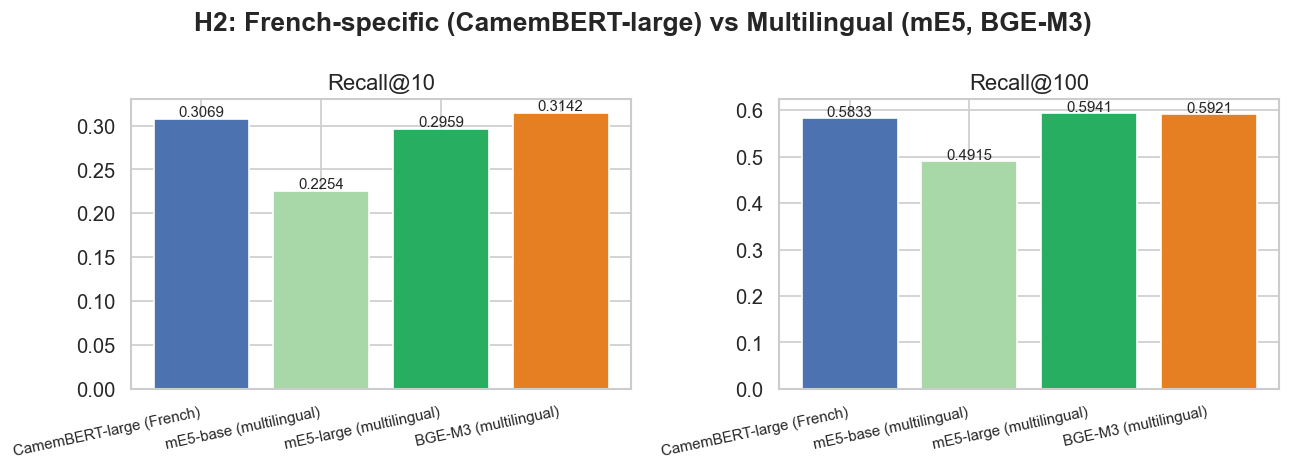

In [10]:
fr_exps = [
    ('dense_camembert_lg_zeroshot',  'CamemBERT-large (French)'),
    ('dense_me5_base_zeroshot',      'mE5-base (multilingual)'),
    ('dense_me5_large_zeroshot',     'mE5-large (multilingual)'),
    ('dense_bge_m3_zeroshot',        'BGE-M3 (multilingual)'),
]
metrics_show = ['Recall@10', 'Recall@100', 'MRR@100', 'MAP@100']

fr_df = pd.DataFrame([
    {'Model': lbl, **{m: raw[s]['metrics'][m] for m in metrics_show}}
    for s, lbl in fr_exps if s in raw
])
display(fr_df.style.hide(axis='index').format({m: '{:.4f}' for m in metrics_show}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['Recall@10', 'Recall@100']):
    cols = ['#4c72b0', '#a8d8a8', '#27ae60', '#e67e22']
    bars = ax.bar(fr_df['Model'], fr_df[metric], color=cols[:len(fr_df)], edgecolor='white')
    for bar, val in zip(bars, fr_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontsize=9)
    ax.set_title(metric); plt.setp(ax.get_xticklabels(), rotation=12, ha='right', fontsize=9)
plt.suptitle('H2: French-specific (CamemBERT-large) vs Multilingual (mE5, BGE-M3)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Qwen3 Instruction Effect — D10 vs D10i

D10i uses a legal instruction prefix on the query side only (corpus embeddings reused from D10).  
Tests whether a task-specific instruction prefix improves the decoder-only model's retrieval.

**Shared costs (D10 → D10i):**
- Corpus encoding: 1983.8 s (33.1 min) on Azure T4 GPU — one-off, fully reused by D10i
- Retrieval latency: ~61.7 ms — identical retrieval path; D10i adds only a fixed query-prefix string


Model,Recall@10,Recall@100,MRR@10,MRR@100,MAP@100,NDCG@10
"Qwen3-0.6B (D10, no prefix)",0.3240,0.5822,0.3068,0.3171,0.1991,0.2594
"Qwen3-0.6B instruct (D10i, legal prefix)",0.3389,0.5974,0.3176,0.3276,0.2063,0.2677


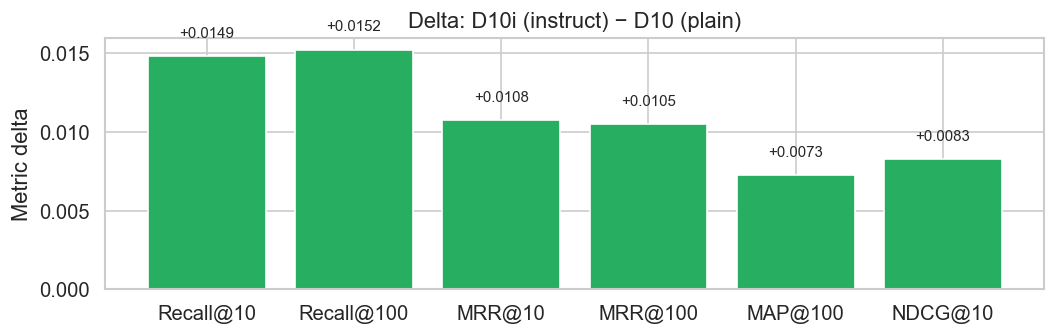

In [11]:
qwen_exps = [
    ('dense_qwen3_0_6b_zeroshot',          'Qwen3-0.6B (D10, no prefix)'),
    ('dense_qwen3_0_6b_instruct_zeroshot', 'Qwen3-0.6B instruct (D10i, legal prefix)'),
]
metrics_show = ['Recall@10', 'Recall@100', 'MRR@10', 'MRR@100', 'MAP@100', 'NDCG@10']

qwen_df = pd.DataFrame([
    {'Model': lbl, **{m: raw[s]['metrics'][m] for m in metrics_show}}
    for s, lbl in qwen_exps if s in raw
])
display(qwen_df.style.hide(axis='index').format({m: '{:.4f}' for m in metrics_show}))

# Delta bar chart
if len(qwen_df) == 2:
    deltas = {m: qwen_df.iloc[1][m] - qwen_df.iloc[0][m] for m in metrics_show}
    fig, ax = plt.subplots(figsize=(9, 3))
    keys = list(deltas.keys()); vals_d = list(deltas.values())
    bars = ax.bar(keys, vals_d, color=['#27ae60' if v >= 0 else '#e74c3c' for v in vals_d])
    ax.axhline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, vals_d):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.001 if val >= 0 else val - 0.002,
                f'{val:+.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    ax.set_title('Delta: D10i (instruct) − D10 (plain)')
    ax.set_ylabel('Metric delta')
    plt.tight_layout(); plt.show()

## 8. Field Weighting Ablation — text_only vs concat_2x (EXP-D7)

The `concat_2x` field builder prepends `law_code` twice before the article text,  
giving a ~2× BM25-style weight to the legal code label without modifying the encoder.

Model,Recall@10,Recall@100,Recall@200,Recall@500,MRR@10,MRR@100,MAP@100,NDCG@10
mE5-large text_only (D4),0.2959,0.5941,0.6753,0.7540,0.2878,0.2995,0.1732,0.2300
mE5-large concat_2x (D7) ★,0.3420,0.6215,0.6978,0.7732,0.3106,0.3217,0.2157,0.2699


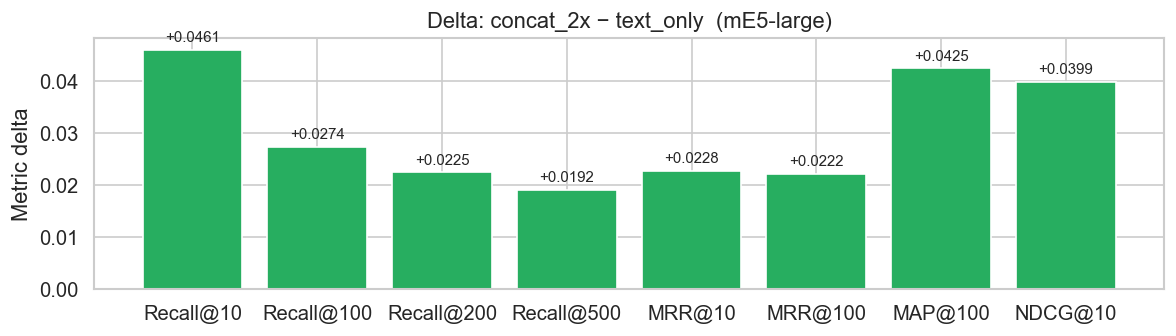

In [12]:
fw_pairs = [
    ('dense_me5_large_zeroshot',          'mE5-large text_only (D4)'),
    ('dense_me5_large_concat2x_zeroshot', 'mE5-large concat_2x (D7) ★'),
]
metrics_show = ['Recall@10', 'Recall@100', 'Recall@200', 'Recall@500',
                'MRR@10', 'MRR@100', 'MAP@100', 'NDCG@10']

fw_df = pd.DataFrame([
    {'Model': lbl, **{m: raw[s]['metrics'][m] for m in metrics_show}}
    for s, lbl in fw_pairs if s in raw
])
display(fw_df.style.hide(axis='index').format({m: '{:.4f}' for m in metrics_show}))

if len(fw_df) == 2:
    deltas = {m: fw_df.iloc[1][m] - fw_df.iloc[0][m] for m in metrics_show}
    fig, ax = plt.subplots(figsize=(10, 3))
    keys = list(deltas.keys()); vals_d = list(deltas.values())
    bars = ax.bar(keys, vals_d, color=['#27ae60' if v >= 0 else '#e74c3c' for v in vals_d])
    ax.axhline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, vals_d):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.001 if val >= 0 else val - 0.002,
                f'{val:+.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    ax.set_title('Delta: concat_2x − text_only  (mE5-large)')
    ax.set_ylabel('Metric delta')
    plt.tight_layout(); plt.show()

## 9. Stratified Analysis — Single vs Multi-Article Queries

Queries with multiple relevant articles cannot reach Recall@10 = 1.0 regardless of retriever quality.  
R@100 is the structurally appropriate metric for multi-article queries.

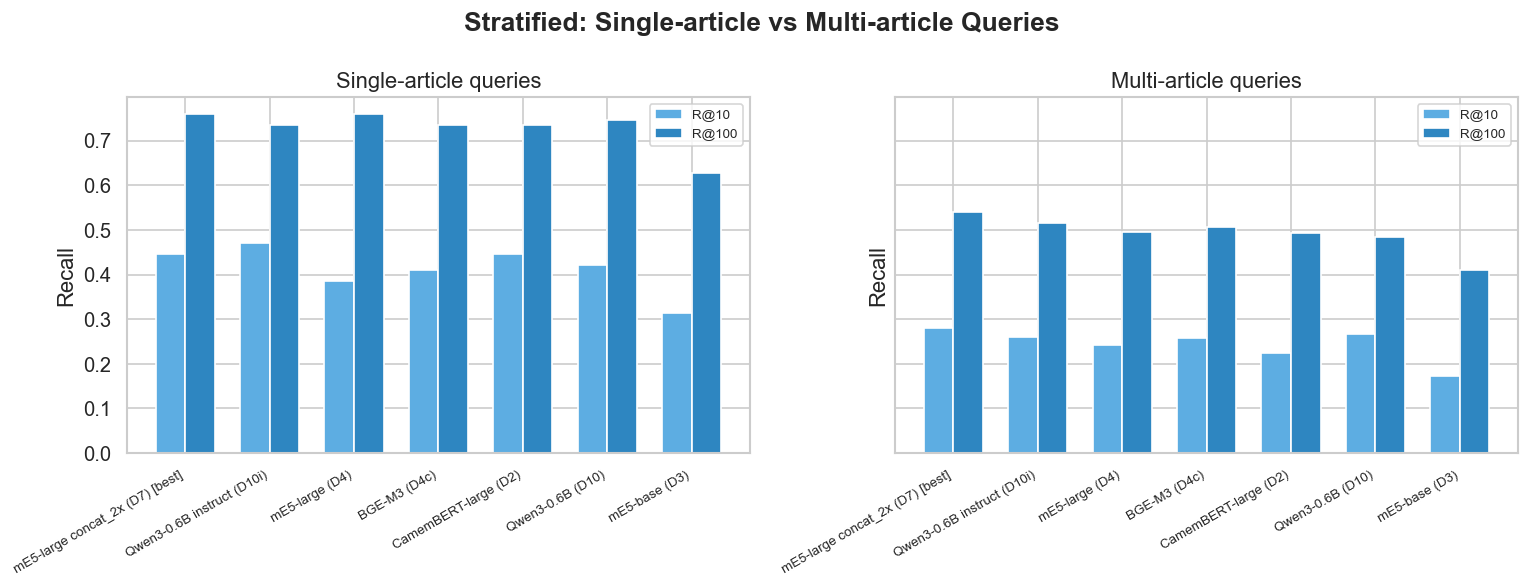

In [13]:
STRATA_PAIRS = [
    ('single_article',  'multi_article',
     'Single-article queries', 'Multi-article queries'),
]

eligible_order = sorted(
    [s for s in raw if s not in EXCLUDED],
    key=lambda s: raw[s]['metrics']['Recall@100'], reverse=True
)

for stratum_a, stratum_b, label_a, label_b in STRATA_PAIRS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (stratum, label) in zip(axes, [(stratum_a, label_a), (stratum_b, label_b)]):
        stems  = [s for s in eligible_order if s in raw]
        r10s   = [raw[s]['stratified'].get(stratum, {}).get('Recall@10',  0) for s in stems]
        r100s  = [raw[s]['stratified'].get(stratum, {}).get('Recall@100', 0) for s in stems]
        lbls   = [SHORT.get(s, s) for s in stems]
        x      = np.arange(len(stems))
        w      = 0.35
        ax.bar(x - w/2, r10s,  w, label='R@10',  color='#5dade2', edgecolor='white')
        ax.bar(x + w/2, r100s, w, label='R@100', color='#2e86c1', edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
        ax.set_title(label); ax.set_ylabel('Recall'); ax.legend(fontsize=8)
    plt.suptitle('Stratified: Single-article vs Multi-article Queries', fontweight='bold')
    plt.tight_layout(); plt.show()

## 10. Stratified Analysis — Lexically Aligned vs Semantically Paraphrased (Hypothesis H5)

**H5:** Dense retrieval (even zero-shot) may outperform BM25 on semantically paraphrased queries  
(~5% R@10 for sparse) while underperforming on lexically aligned queries where BM25 achieves ~50% R@10.

This is the primary motivation for Tier 2: closing the semantic paraphrasing gap.

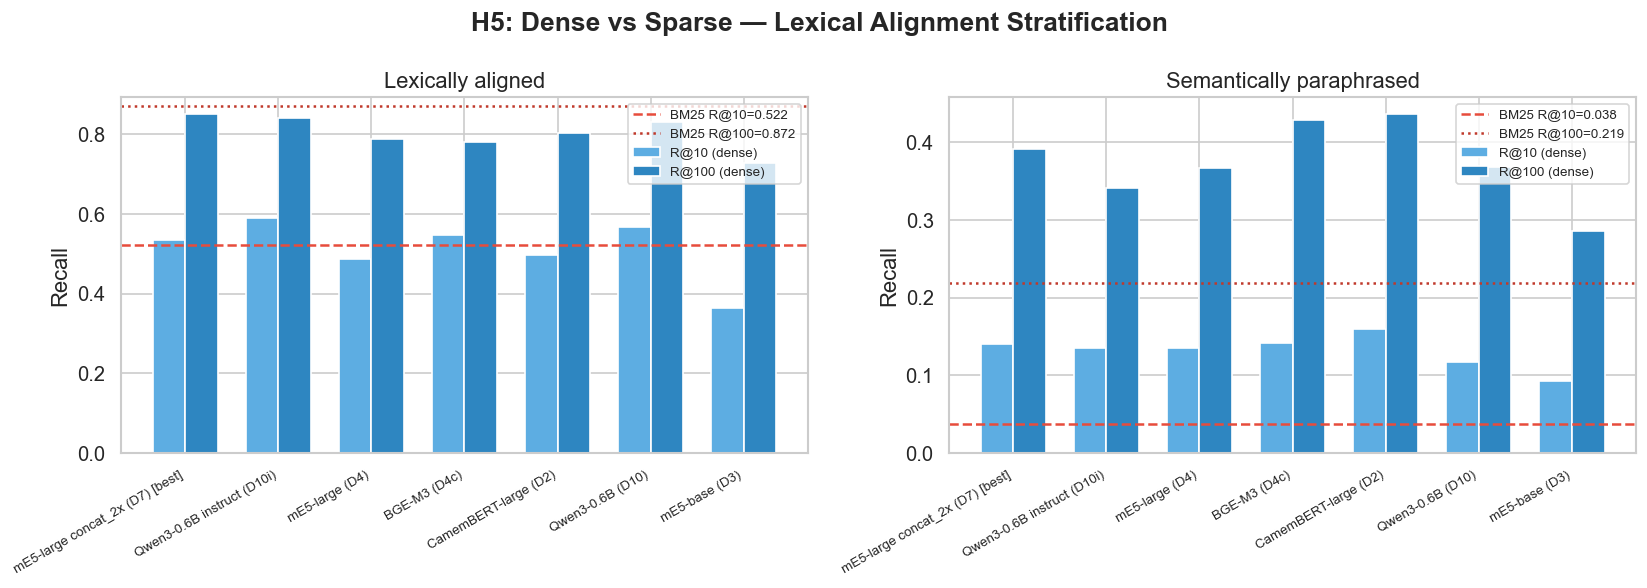

In [14]:
lex_strata  = ['lexically_aligned', 'semantically_paraphrased']
lex_labels  = ['Lexically aligned', 'Semantically paraphrased']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (stratum, label) in zip(axes, zip(lex_strata, lex_labels)):
    stems  = [s for s in eligible_order if s in raw]
    r10s   = [raw[s]['stratified'].get(stratum, {}).get('Recall@10',  0) for s in stems]
    r100s  = [raw[s]['stratified'].get(stratum, {}).get('Recall@100', 0) for s in stems]
    lbls   = [SHORT.get(s, s) for s in stems]

    # Add sparse anchor
    if SPARSE_BEST_KEY in sparse_raw:
        sp = sparse_raw[SPARSE_BEST_KEY]
        ref_r10  = sp['stratified'].get(stratum, {}).get('Recall@10',  0)
        ref_r100 = sp['stratified'].get(stratum, {}).get('Recall@100', 0)

    x = np.arange(len(stems))
    w = 0.35
    ax.bar(x - w/2, r10s,  w, label='R@10 (dense)',  color='#5dade2', edgecolor='white')
    ax.bar(x + w/2, r100s, w, label='R@100 (dense)', color='#2e86c1', edgecolor='white')
    if SPARSE_BEST_KEY in sparse_raw:
        ax.axhline(ref_r10,  color=SPARSE_COLOR, linestyle='--', linewidth=1.5,
                   label=f'BM25 R@10={ref_r10:.3f}')
        ax.axhline(ref_r100, color='#c0392b', linestyle=':', linewidth=1.5,
                   label=f'BM25 R@100={ref_r100:.3f}')
    ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
    ax.set_title(label); ax.set_ylabel('Recall'); ax.legend(fontsize=8)

plt.suptitle('H5: Dense vs Sparse — Lexical Alignment Stratification', fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Stratified Analysis — Cross-Reference Articles

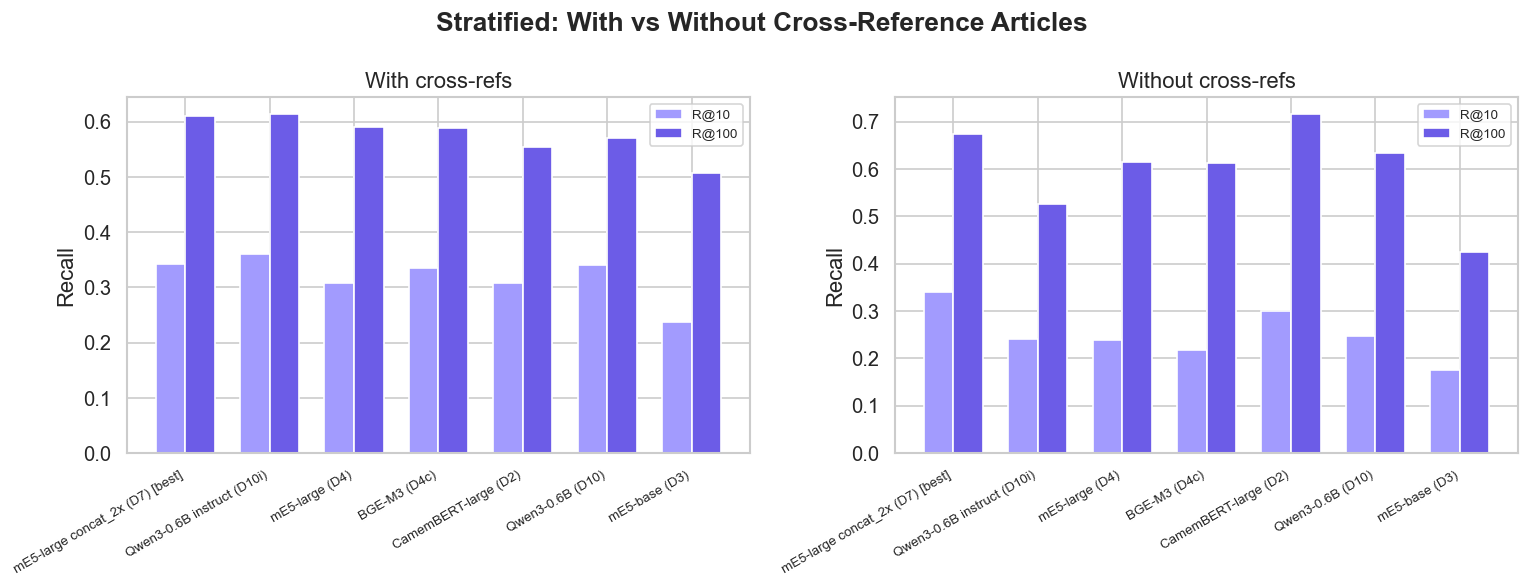

In [15]:
xref_strata = ['with_cross_refs', 'without_cross_refs']
xref_labels = ['With cross-refs', 'Without cross-refs']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (stratum, label) in zip(axes, zip(xref_strata, xref_labels)):
    stems  = [s for s in eligible_order if s in raw]
    r10s   = [raw[s]['stratified'].get(stratum, {}).get('Recall@10',  0) for s in stems]
    r100s  = [raw[s]['stratified'].get(stratum, {}).get('Recall@100', 0) for s in stems]
    lbls   = [SHORT.get(s, s) for s in stems]
    x = np.arange(len(stems)); w = 0.35
    ax.bar(x - w/2, r10s,  w, label='R@10',  color='#a29bfe', edgecolor='white')
    ax.bar(x + w/2, r100s, w, label='R@100', color='#6c5ce7', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
    ax.set_title(label); ax.set_ylabel('Recall'); ax.legend(fontsize=8)
plt.suptitle('Stratified: With vs Without Cross-Reference Articles', fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Dense vs Sparse — Head-to-Head Across All Strata

Best dense model (D7 mE5-large concat_2x) vs best sparse model (bm25_lemmatize_concat_2x).  
Shows which retrieval paradigm wins on each failure stratum.

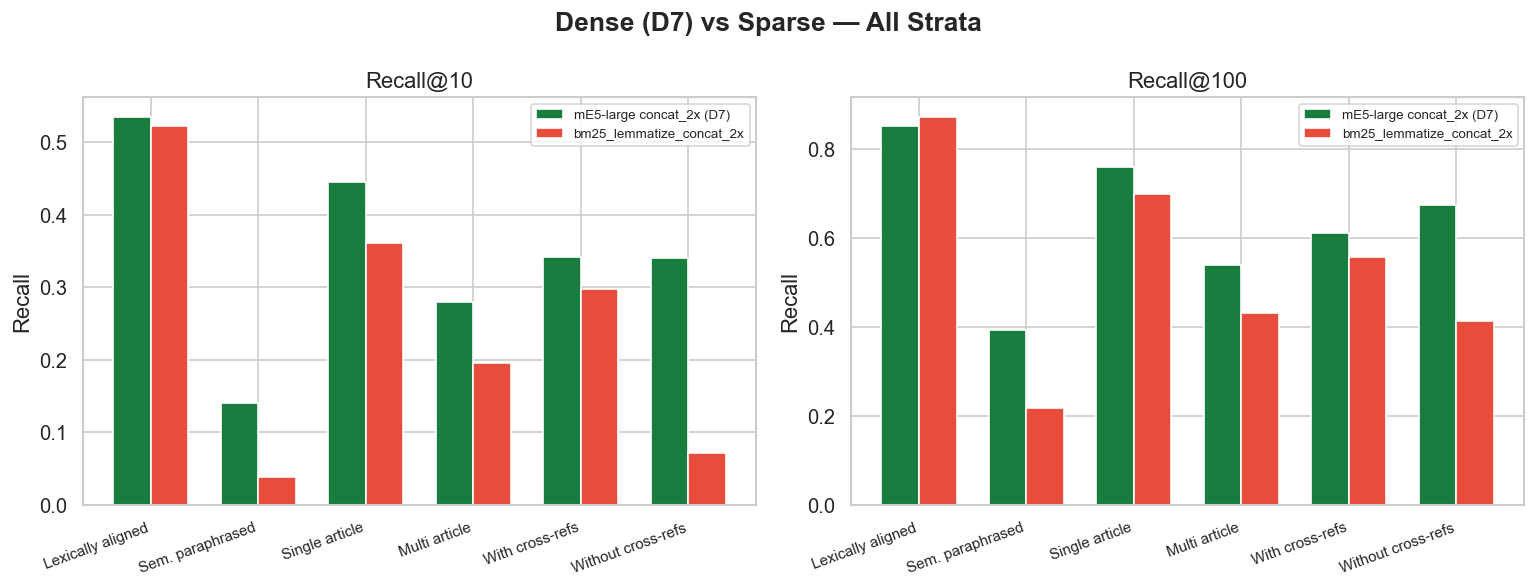

In [16]:
BEST_DENSE = 'dense_me5_large_concat2x_zeroshot'

all_strata = [
    ('lexically_aligned',        'Lexically aligned'),
    ('semantically_paraphrased', 'Sem. paraphrased'),
    ('single_article',           'Single article'),
    ('multi_article',            'Multi article'),
    ('with_cross_refs',          'With cross-refs'),
    ('without_cross_refs',       'Without cross-refs'),
]

if BEST_DENSE in raw and SPARSE_BEST_KEY in sparse_raw:
    dense_d  = raw[BEST_DENSE]
    sparse_d = sparse_raw[SPARSE_BEST_KEY]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric in zip(axes, ['Recall@10', 'Recall@100']):
        strat_lbls  = [lbl for _, lbl in all_strata]
        dense_vals  = [dense_d['stratified'].get(s, {}).get(metric, 0)  for s, _ in all_strata]
        sparse_vals = [sparse_d['stratified'].get(s, {}).get(metric, 0) for s, _ in all_strata]
        x = np.arange(len(all_strata)); w = 0.35
        ax.bar(x - w/2, dense_vals,  w, label='mE5-large concat_2x (D7)',   color='#1a7d40', edgecolor='white')
        ax.bar(x + w/2, sparse_vals, w, label='bm25_lemmatize_concat_2x', color=SPARSE_COLOR,  edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(strat_lbls, rotation=20, ha='right', fontsize=9)
        ax.set_title(metric); ax.set_ylabel('Recall'); ax.legend(fontsize=8)
    plt.suptitle('Dense (D7) vs Sparse — All Strata', fontweight='bold')
    plt.tight_layout(); plt.show()

## 13. Latency vs R@100 Trade-off (Tier 0)

**Hardware note:** Encoder-only models (D1–D6) were run on a local CPU.  
Qwen3 models (D10, D10i) were run on Azure ML **Tesla T4 GPU** (16 GB).  
Latency values are **not directly comparable** across these two groups —  
they reflect different hardware and should be interpreted within each group only.

**Qwen3 latency (GPU — Azure T4):**
- D10 (Qwen3-0.6B): ~61.7 ms mean retrieval latency
- D10i (Qwen3-0.6B instruct): same latency as D10 (~61.7 ms) — query-side prefix only, identical retrieval path


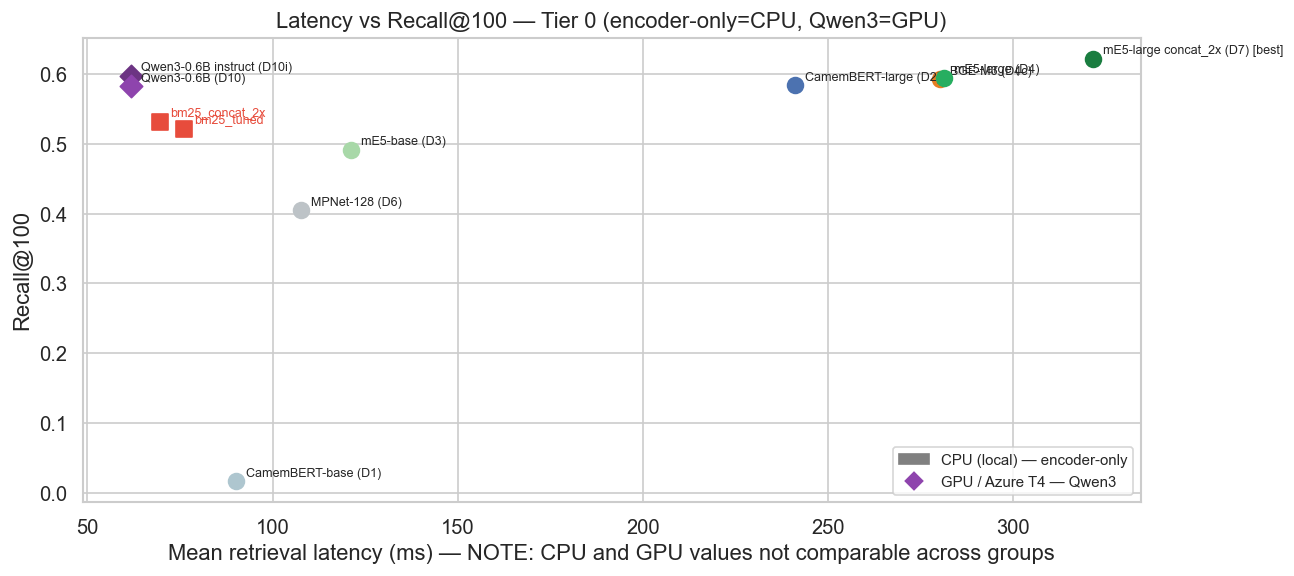

In [17]:
QWEN3_STEMS = {"dense_qwen3_0_6b_zeroshot", "dense_qwen3_0_6b_instruct_zeroshot"}

fig, ax = plt.subplots(figsize=(11, 5))

D10_STEM   = "dense_qwen3_0_6b_zeroshot"
D10I_STEM  = "dense_qwen3_0_6b_instruct_zeroshot"
# D10i reuses D10 corpus embeddings; assign same latency for comparability
_d10_lat = raw[D10_STEM]["metrics"].get("T0/latency_mean_ms",
          raw[D10_STEM].get("latency_ms_mean", 0))

for stem, d in raw.items():
    m    = d["metrics"]
    lat  = _d10_lat if stem == D10I_STEM else m.get("T0/latency_mean_ms", d.get("latency_ms_mean", 0))
    r100 = m["Recall@100"]
    color  = COLORS.get(stem, "#555")
    marker = "D" if stem in QWEN3_STEMS else "o"   # diamond = GPU
    ax.scatter(lat, r100, color=color, s=90, marker=marker, zorder=3)
    ax.annotate(SHORT.get(stem, stem), (lat, r100),
                textcoords="offset points", xytext=(6, 3), fontsize=7.5)

for key, lbl in [(SPARSE_ANCHOR_KEY, "bm25_tuned"), (SPARSE_BEST_KEY, "bm25_concat_2x")]:
    if key in sparse_raw:
        m    = sparse_raw[key]["metrics"]
        lat  = m.get("T0/latency_mean_ms", 0)
        r100 = m["Recall@100"]
        ax.scatter(lat, r100, color=SPARSE_COLOR, marker="s", s=90, zorder=3)
        ax.annotate(lbl, (lat, r100), textcoords="offset points",
                    xytext=(6, 3), fontsize=7.5, color=SPARSE_COLOR)

# Legend
cpu_patch = mpatches.Patch(color="grey", label="CPU (local) — encoder-only")
gpu_patch = plt.Line2D([0], [0], marker="D", color="w",
                        markerfacecolor="#8e44ad", markersize=9,
                        label="GPU / Azure T4 — Qwen3")
ax.legend(handles=[cpu_patch, gpu_patch], fontsize=9)

ax.set_xlabel("Mean retrieval latency (ms) — NOTE: CPU and GPU values not comparable across groups")
ax.set_ylabel("Recall@100")
ax.set_title("Latency vs Recall@100 — Tier 0 (encoder-only=CPU, Qwen3=GPU)")
plt.tight_layout()
plt.show()

## 14. Corpus Encoding Time (Tier 0 – One-off Cost)

**Hardware note:**
- Encoder-only models (D1–D4c, D6): encoded on **local CPU**
- Qwen3-0.6B (D10): encoded on **Azure ML Tesla T4 GPU** (batch_size=4, 1983.8 s = 33.1 min)
- Qwen3-0.6B instruct (D10i): same index as D10 (1983.8 s shared one-off cost; query-side prefix only)

CPU and GPU encoding times are shown on the same chart for completeness but  
**should not be compared directly.** GPU encoding is ~5–15× faster than CPU for these model sizes.


Model,Hardware,Source,Encode (s),Encode (h),R@100
BGE-M3 (D4c),CPU (local),encode,29616,8.23,0.5921
mE5-large concat_2x (D7) [best],CPU (local),encode,29470,8.19,0.6215
mE5-large (D4),CPU (local),encode,21054,5.85,0.5941
CamemBERT-large (D2),CPU (local),encode,18677,5.19,0.5833
CamemBERT-base (D1),CPU (local),encode,5437,1.51,0.0169
MPNet-128 (D6),CPU (local),encode,3652,1.01,0.4047
Qwen3-0.6B instruct (D10i),GPU (Azure T4),encode,1984,0.55,0.5974
Qwen3-0.6B (D10),GPU (Azure T4),encode,1984,0.55,0.5822
mE5-base (D3),CPU (local),disk,0,0.00,0.4915


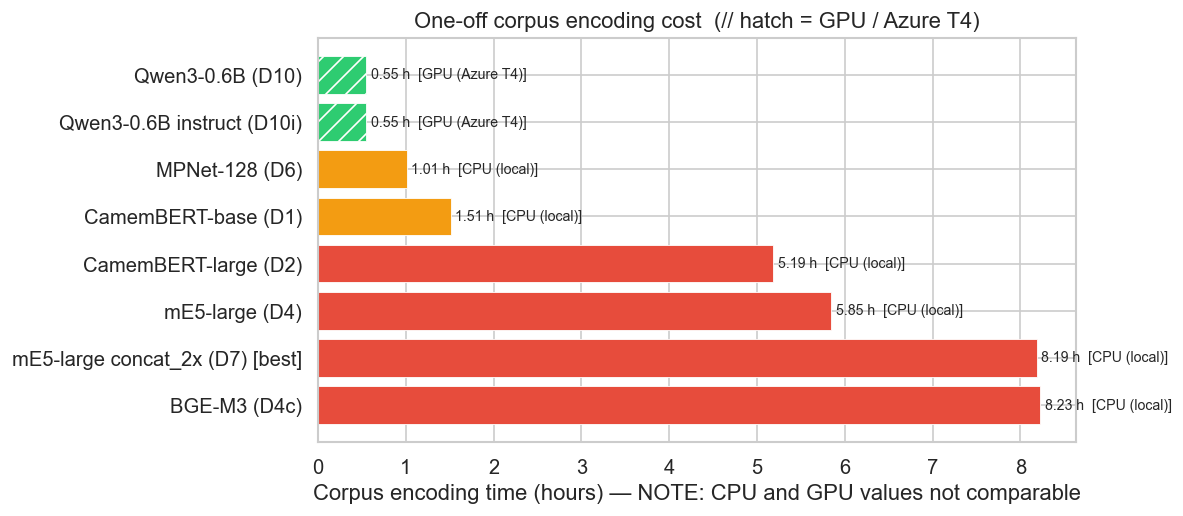

Note: D10i (Qwen3 instruct) shares D10Â's corpus index (1983.8 s one-off cost attributed to D10).
      All Qwen3 latency values (retrieval path) were also measured on GPU.


In [18]:
QWEN3_STEMS = {"dense_qwen3_0_6b_zeroshot", "dense_qwen3_0_6b_instruct_zeroshot"}

_d10_build_s = raw[D10_STEM]["metrics"].get("T0/breakdown/index_build_s", 0)

enc_rows = []
for stem, d in raw.items():
    # D10i reuses D10 corpus index — assign shared encoding cost
    build_s   = _d10_build_s if stem == D10I_STEM else d["metrics"].get("T0/breakdown/index_build_s", 0)
    build_src = "encode" if stem == D10I_STEM else d.get("index_build_source", "?")
    hw        = "GPU (Azure T4)" if stem in QWEN3_STEMS else "CPU (local)"
    enc_rows.append({
        "Model":      SHORT.get(stem, stem),
        "Hardware":   hw,
        "Source":     build_src,
        "Encode (s)": build_s if build_src == "encode" else 0,
        "Encode (h)": build_s / 3600 if build_src == "encode" else 0,
        "R@100":      d["metrics"]["Recall@100"],
    })

enc_df = pd.DataFrame(enc_rows).sort_values("Encode (s)", ascending=False)
display(enc_df.style.hide(axis="index").format({
    "Encode (s)": "{:.0f}", "Encode (h)": "{:.2f}", "R@100": "{:.4f}"
}))

enc_plot = enc_df[enc_df["Encode (s)"] > 60].copy()
if not enc_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    hours      = enc_plot["Encode (h)"]
    bar_colors = ["#e74c3c" if h > 4 else "#f39c12" if h > 1 else "#2ecc71" for h in hours]
    hatches    = ["//" if "GPU" in hw else "" for hw in enc_plot["Hardware"]]
    bars = ax.barh(enc_plot["Model"], hours, color=bar_colors,
                   hatch=hatches, edgecolor="white", linewidth=0.5)
    for bar, val, hw in zip(bars, hours, enc_plot["Hardware"]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} h  [{hw}]", va="center", fontsize=8.5)
    ax.set_xlabel("Corpus encoding time (hours) — NOTE: CPU and GPU values not comparable")
    ax.set_title("One-off corpus encoding cost  (// hatch = GPU / Azure T4)")
    plt.tight_layout(); plt.show()

print("Note: D10i (Qwen3 instruct) shares D10Â's corpus index (1983.8 s one-off cost attributed to D10).")
print("      All Qwen3 latency values (retrieval path) were also measured on GPU.")

## 15. Significance Testing Summary

In [19]:
sig_rows = []
for stem, d in sorted(raw.items(), key=lambda x: x[1]['metrics']['Recall@100'], reverse=True):
    sig = d.get('significance_vs_anchor', {})
    m   = d['metrics']
    sig_rows.append({
        'Experiment':  SHORT.get(stem, stem),
        'R@10':        m['Recall@10'],
        'R@100':       m['Recall@100'],
        'p (R@100)':   sig.get('p_value_recall100'),
        'p (R@10)':    sig.get('p_value_recall10'),
        'sig':         sig.get('significant'),
    })

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.hide(axis='index').format({
    'R@10': '{:.4f}', 'R@100': '{:.4f}',
    'p (R@100)': '{:.4f}', 'p (R@10)': '{:.4f}',
}, na_rep='—'))
print('\nAnchor: bm25_tuned (k1=1.5, b=0.5, lemmatize) — inline BM25 built at experiment runtime')
print('Test: two-sided paired t-test on per-query Recall@100 (primary) and Recall@10 (secondary)')

Experiment,R@10,R@100,p (R@100),p (R@10),sig
mE5-large concat_2x (D7) [best],0.3420,0.6215,0.0003,0.0079,True
Qwen3-0.6B instruct (D10i),0.3389,0.5974,0.0045,0.0025,True
mE5-large (D4),0.2959,0.5941,0.0095,0.2246,True
BGE-M3 (D4c),0.3142,0.5921,0.0150,0.0301,True
CamemBERT-large (D2),0.3069,0.5833,0.0476,0.1117,True
Qwen3-0.6B (D10),0.3240,0.5822,0.0274,0.0148,True
mE5-base (D3),0.2254,0.4915,0.2062,0.1179,False
MPNet-128 (D6),0.2108,0.4047,0.0005,0.0401,True
CamemBERT-base (D1),0.0077,0.0169,0.0000,0.0000,True



Anchor: bm25_tuned (k1=1.5, b=0.5, lemmatize) — inline BM25 built at experiment runtime
Test: two-sided paired t-test on per-query Recall@100 (primary) and Recall@10 (secondary)


## 16. Model Selection for Tier 3

In [20]:
# Eligible: exclude D1 (paper anchor only), D6 (128-token reference), Qwen3 (decoder-only)
EXCLUDED_T3 = {
    'dense_camembert_base_zeroshot',
    'dense_mpnet_multi_zeroshot',
    'dense_qwen3_0_6b_zeroshot',
    'dense_qwen3_0_6b_instruct_zeroshot',
}

t3_rows = []
for stem, d in raw.items():
    if stem in EXCLUDED_T3:
        continue
    m = d['metrics']
    t3_rows.append({
        'Experiment': SHORT.get(stem, stem),
        'R@10':       m['Recall@10'],
        'R@100':      m['Recall@100'],
        'MRR@100':    m['MRR@100'],
        'MAP@100':    m['MAP@100'],
    })

t3_df = pd.DataFrame(t3_rows).sort_values('R@100', ascending=False).reset_index(drop=True)
t3_df.index = t3_df.index + 1
display(t3_df.style.format({m: '{:.4f}' for m in ['R@10','R@100','MRR@100','MAP@100']}))

winner = t3_df.iloc[0]
print(f'\n>>> Tier 3 dense component: {winner["Experiment"]}')
print(f'    R@10={winner["R@10"]:.4f}  R@100={winner["R@100"]:.4f}  MRR@100={winner["MRR@100"]:.4f}')

sp_r100 = sparse_raw[SPARSE_BEST_KEY]['metrics']['Recall@100'] if SPARSE_BEST_KEY in sparse_raw else 0
print(f'    vs bm25_lemmatize_concat_2x R@100={sp_r100:.4f}')
print(f'    Dense improvement: {winner["R@100"] - sp_r100:+.4f}')

,Experiment,R@10,R@100,MRR@100,MAP@100
1,mE5-large concat_2x (D7) [best],0.3420,0.6215,0.3217,0.2157
2,mE5-large (D4),0.2959,0.5941,0.2995,0.1732
3,BGE-M3 (D4c),0.3142,0.5921,0.3034,0.1815
4,CamemBERT-large (D2),0.3069,0.5833,0.2522,0.1620
5,mE5-base (D3),0.2254,0.4915,0.2448,0.1404



>>> Tier 3 dense component: mE5-large concat_2x (D7) [best]
    R@10=0.3420  R@100=0.6215  MRR@100=0.3217
    vs bm25_lemmatize_concat_2x R@100=0.5312
    Dense improvement: +0.0903


## 17. Summary of Key Findings

*Fill in after reviewing the plots above.*

| Finding | Hypothesis | Evidence |
|---|---|---|
| | H1 | |
| | H2 | |
| | H3 | |
| | H5 | |
| | H6 | |
| | H8 | |

---

### 17.1 Overall performance vs sparse baseline

*[Fill in after reviewing Section A and the Recall@k curves.]*

### 17.2 Architecture comparison (H8: Qwen3 vs encoder-only)

*[Fill in after reviewing Section 4.]*

### 17.3 Semantic paraphrasing gap (H5)

*[Fill in after reviewing Section 10 — the most important finding for the thesis.]*

### 17.4 Tier 3 selection

*[Confirm winner from Section 16 and record in PROPOSAL_PLAN.md Decision Log.]*